# <font style="font-family:roboto;color:#455e6c"> Parametrising a Machine Learning Interatomic Potential </font>  

<div class="admonition note" name="html-admonition" style="background:#e3f2fd; padding: 10px">
<font style="font-family:roboto;color:#455e6c"> <b> DPG Tutorial: Automated Workflows and Machine Learning for Materials Science Simulations </b> </font> </br>
<font style="font-family:roboto;color:#455e6c"> 16 March 2025 </font> </br> </br>
Marvin Poul, Sarath Menon, Haitham Gaafer, Jörg Neugebauer </br>
<i> Max Planck Institute for Sustainable Materials </i></br>
</br>
Minaam Qamar, Ralf Drautz </br>
<i> Ruhr-Universität Bochum </i></br>
</br>
Tilmann Hickel </br>
<i> Bundesanstalt für Materialforschung und -prüfung </i></br>
</div>

### References

- [Lysogorskiy, Y. et al. Performant implementation of the atomic cluster expansion (PACE) and application to copper and silicon. npj Comput Mater 7, 97 (2021)](http://www.nature.com/articles/s41524-021-00559-9)

In this notebook we fit an [Atomic Cluster Expansion](https://doi.org/10.1103/PhysRevB.99.014104) interatomic potential using the [pacemaker](https://www.nature.com/articles/s41524-021-00559-9) software.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pyiron_core import PyironFlow, Workflow, as_function_node

In [2]:
from dataclasses import asdict, dataclass, field
from typing import List, Optional, Union

In [3]:
@dataclass
class EmbeddingsALL:
    npot: str = "FinnisSinclairShiftedScaled"
    fs_parameters: list[int] = field(default_factory=lambda: [1, 1])
    ndensity: int = 1


@dataclass
class Embeddings:
    ALL: EmbeddingsALL = field(default_factory=EmbeddingsALL)


@dataclass
class BondsALL:
    radbase: str = "SBessel"
    radparameters: list[float] = field(default_factory=lambda: [5.25])
    rcut: float | int = 7.0
    dcut: float = 0.01


@dataclass
class Bonds:
    ALL: BondsALL = field(default_factory=BondsALL)


@dataclass
class FunctionsALL:
    nradmax_by_orders: list[int] = field(default_factory=lambda: [15, 3, 2, 1])
    lmax_by_orders: list[int] = field(default_factory=lambda: [0, 3, 2, 1])


@dataclass
class Functions:
    number_of_functions_per_element: Optional[int] = None
    ALL: FunctionsALL = field(default_factory=FunctionsALL)


@dataclass
class PotentialConfig:
    deltaSplineBins: float = 0.001
    elements: list[str] | None = None

    embeddings: Embeddings = field(default_factory=Embeddings)
    bonds: Bonds = field(default_factory=Bonds)
    functions: Functions = field(default_factory=Functions)

    def __post_init__(self):
        if not isinstance(self.embeddings, Embeddings):
            self.embeddings = Embeddings()
        if not isinstance(self.bonds, Bonds):
            self.bonds = Bonds()
        if not isinstance(self.functions, Functions):
            self.functions = Functions()

    def to_dict(self):
        def remove_none(d):
            """Recursively remove None values from dictionaries."""
            if isinstance(d, dict):
                return {k: remove_none(v) for k, v in d.items() if v is not None}
            elif isinstance(d, list):
                return [remove_none(v) for v in d if v is not None]
            else:
                return d

        return remove_none(asdict(self))

In [4]:
@as_function_node
def ReadPickledDatasetAsDataframe(
    file_path: str = "", compression: Optional[str] = None
):

    from ase.atoms import Atoms as aseAtoms

    df = pd.read_pickle(file_path, compression=compression)

    # Atoms check
    if "atoms" in df.columns:
        at = df.iloc[0]["atoms"]
        # Checking that the elements themselves have the correct atoms format
        if isinstance(at, aseAtoms):
            df.rename(columns={"atoms": "ase_atoms"}, inplace=True)
    elif "ase_atoms" not in df.columns:
        raise ValueError(
            "DataFrame should contain 'atoms' or 'ase_atoms' (ASE atoms) columns"
        )

    # NUMBER OF ATOMS check
    if "NUMBER_OF_ATOMS" not in df.columns and "number_of_atoms" in df.columns:
        df.rename(columns={"number_of_atoms": "NUMBER_OF_ATOMS"}, inplace=True)

    df["NUMBER_OF_ATOMS"] = df["NUMBER_OF_ATOMS"].astype(int)

    # energy corrected check
    if "energy_corrected" not in df.columns and "energy" in df.columns:
        df.rename(columns={"energy": "energy_corrected"}, inplace=True)

    if "pbc" not in df.columns:
        df["pbc"] = df["ase_atoms"].map(lambda atoms: np.all(atoms.pbc))

    return df


@as_function_node
def ParameterizePotentialConfig(
    nrad_max: tuple | list = (15, 6, 4, 1),
    l_max: tuple | list = (0, 6, 5, 1),
    number_of_functions_per_element: int = 10,
    rcut: float = 7.0,
):

    potential_config = PotentialConfig()

    potential_config.bonds.ALL.rcut = rcut
    potential_config.functions.ALL.nradmax_by_orders = list(nrad_max)
    potential_config.functions.ALL.lmax_by_orders = list(l_max)
    potential_config.functions.number_of_functions_per_element = (
        number_of_functions_per_element
    )

    return potential_config


@as_function_node
def SplitTrainingAndTesting(
    data_df: pd.DataFrame, training_frac: float = 0.5, random_state: int = 42
):
    """
    Splits the filtered dataframe into training and testing sets based on a fraction of the dataset

    Args:
        data_df: A pandas.DataFrame of the filtered data DataFrame
        training_frac: A float number which dictates what is the precentage of the dataset to be used for training should be set between 0 to 1
        random_state (default = 42): Sets the random seed used to shuffle the data

    Returns:
        df_training: The training dataframe
        df_testing: The testing dataframe
    """
    if isinstance(training_frac, float):
        training_frac = np.abs(training_frac)

    if training_frac > 1:
        print("""
            Can't have the training dataset more than 100 % of the dataset
            Setting the value to 100%
            """)
        training_frac = 1
    elif training_frac == 0:
        print("Can'fit with no training dataset\nSetting the value to 1%")
        training_frac = 0.01
    df_training = data_df.sample(frac=training_frac, random_state=random_state)
    df_testing = data_df.loc[(i for i in data_df.index if i not in df_training.index)]

    return df_training, df_testing


@as_function_node
def RunLinearFit(
    potential_config,
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    verbose: bool = False,
    store: bool = True,
):

    from pyace import create_multispecies_basis_config
    from pyace.linearacefit import LinearACEDataset, LinearACEFit
    from pyiron_snippets.logger import logger

    logger.setLevel(30)

    elements_set = set()
    for at in df_train["ase_atoms"]:
        elements_set.update(at.get_chemical_symbols())
    for at in df_test["ase_atoms"]:
        elements_set.update(at.get_chemical_symbols())

    elements = sorted(elements_set)
    potential_config.elements = elements
    potential_config_dict = potential_config.to_dict()

    bconf = create_multispecies_basis_config(potential_config_dict)

    train_ds = LinearACEDataset(bconf, df_train)
    train_ds.construct_design_matrix(verbose=verbose)
    if df_test.empty is False:
        test_ds = LinearACEDataset(bconf, df_test)
        test_ds.construct_design_matrix(verbose=verbose)
    else:
        test_ds = None

    linear_fit = LinearACEFit(train_dataset=train_ds)
    linear_fit.fit()

    training_dict = linear_fit.compute_errors(train_ds)
    training_e_rmse = round(training_dict["epa_rmse"] * 1000, 2)
    training_f_rmse = round(training_dict["f_comp_rmse"] * 1000, 2)
    print("====================== TRAINING INFO ======================")
    print(f"Training E RMSE: {training_e_rmse:.2f} meV/atom")
    print(f"Training F RMSE: {training_f_rmse:.2f} meV/A")

    if test_ds is not None:
        testing_dict = linear_fit.compute_errors(test_ds)
        testing_e_rmse = round(testing_dict["epa_rmse"] * 1000, 2)
        testing_f_rmse = round(testing_dict["f_comp_rmse"] * 1000, 2)
        print("======================= TESTING INFO =======================")
        print(f"Testing E RMSE: {testing_e_rmse:.2f} meV/atom")
        print(f"Testing F RMSE: {testing_f_rmse:.2f} meV/A")

    basis = linear_fit.get_bbasis()
    return basis


@as_function_node
def SavePotential(basis, filename: str = ""):
    import os

    if filename == "":
        filename = f"{'_'.join(basis.elements_name)}_linear_potential"
        folder_name = "Linear_ace_potentials"
    else:
        folder_name = os.path.dirname(filename)
        filename = os.path.basename(filename)

    folder_name = "Linear_ace_potentials"
    os.makedirs(folder_name, exist_ok=True)

    current_path = os.getcwd()
    folder_path = current_path + "/" + folder_name
    # Saving yaml and yace files
    print(
        f'Potentials "{filename}.yaml" and "{filename}.yace" are saved in "{folder_path}".'
    )

    yace_file_path = f"{folder_path}/{filename}.yace"
    basis.save(f"{folder_path}/{filename}.yaml")
    basis.to_ACECTildeBasisSet().save_yaml(yace_file_path)

    return basis, yace_file_path


@as_function_node
def PredictEnergiesAndForces(
    basis, df_train: pd.DataFrame, df_test: pd.DataFrame, store: bool = True
):

    from pyace import PyACECalculator

    data_dict = {}

    ace = PyACECalculator(basis)

    training_structures = df_train.ase_atoms

    # Reference data
    training_number_of_atoms = df_train.NUMBER_OF_ATOMS.to_numpy()
    training_energies = df_train.energy_corrected.to_numpy()

    training_epa = training_energies / training_number_of_atoms
    training_fpa = np.concatenate(df_train.forces.to_numpy()).flatten()
    data_dict["reference_training_epa"] = training_epa
    data_dict["reference_training_fpa"] = training_fpa

    # Predicted data
    training_predict = _get_predicted_energies_forces(
        ace=ace, structures=training_structures
    )
    data_dict["predicted_training_epa"] = (
        np.array(training_predict[0]) / training_number_of_atoms
    )
    data_dict["predicted_training_fpa"] = np.concatenate(training_predict[1]).flatten()

    if df_test.empty is False:

        testing_structures = df_test.ase_atoms

        # Reference data
        testing_number_of_atoms = df_test.NUMBER_OF_ATOMS.to_numpy()
        testing_energies = df_test.energy_corrected.to_numpy()

        testing_epa = testing_energies / testing_number_of_atoms
        testing_fpa = np.concatenate(df_test.forces.to_numpy()).flatten()
        data_dict["reference_testing_epa"] = testing_epa
        data_dict["reference_testing_fpa"] = testing_fpa

        # Predicted data
        testing_predict = _get_predicted_energies_forces(
            ace=ace, structures=testing_structures
        )
        data_dict["predicted_testing_epa"] = (
            np.array(testing_predict[0]) / testing_number_of_atoms
        )
        data_dict["predicted_testing_fpa"] = np.concatenate(
            testing_predict[1]
        ).flatten()

    return data_dict


def _get_predicted_energies_forces(ace, structures):
    forces = []
    energies = []

    for s in structures:
        s.calc = ace
        energies.append(s.get_potential_energy())
        forces.append(s.get_forces())
        s.calc = None
    return energies, forces


def _calc_rmse(array_1, array_2, rmse_in_milli: bool = True):
    """
    Calculates the RMSE value of two arrays

    Args:
    array_1: An array or list of energy or force values
    array_2: An array or list of energy or force values

    Returns:
    rmse_in_milli: (boolean, Default = True) Set False if you want the calculated RMSE value in decimals
    rmse: The calculated RMSE value
    """
    rmse = np.sqrt(np.mean((array_1 - array_2) ** 2))
    if rmse_in_milli:
        return rmse * 1000
    else:
        return rmse


def make_linearfit(
    workflow_name: str,
    delete_existing_savefiles=False,
    file_path: str = "mgca.pckl.tgz",
    compression: str | None = None,
    training_frac: float | int = 0.5,
    number_of_functions_per_element: int | None = 10,
    rcut: float | int = 6.0,
):

    wf = Workflow(workflow_name, delete_existing_savefiles=delete_existing_savefiles)
    if wf.has_saved_content():
        return wf

    # Workflow connections
    wf.load_dataset = ReadPickledDatasetAsDataframe(
        file_path=file_path, compression=compression
    )
    wf.split_dataset = SplitTrainingAndTesting(
        data_df=wf.load_dataset.outputs.df, training_frac=training_frac
    )
    wf.parameterize_potential = ParameterizePotentialConfig(
        number_of_functions_per_element=number_of_functions_per_element, rcut=rcut
    )
    wf.run_linear_fit = RunLinearFit(
        potential_config=wf.parameterize_potential,
        df_train=wf.split_dataset.outputs.df_training,
        df_test=wf.split_dataset.outputs.df_testing,
        verbose=False,
    )
    wf.save_potential = SavePotential(basis=wf.run_linear_fit.outputs.basis)
    wf.predict_energies_forces = PredictEnergiesAndForces(
        basis=wf.save_potential.outputs.basis,
        df_train=wf.split_dataset.outputs.df_training,
        df_test=wf.split_dataset.outputs.df_testing,
    )

    # Input mapping
    wf.inputs_map = {
        "run_linear_fit__verbose": "verbose",
        "save_potential__filename": "filename",
        "parameterize_potential__number_of_functions_per_element": "number_of_functions_per_element",
        "parameterize_potential__rcut": "rcut",
    }

    # Output maping
    wf.outputs_map = {
        "save_potential__yace_file_path": "yace_file_path",
        "predict_energies_forces__data_dict": "data_dict",
    }

    return wf


########################## PLOTTING NODES ##########################


# HISTOGRAM FOR ENERGY DISTRIBUTION
@as_function_node("plot")
def PlotEnergyHistogram(df: "pd.DataFrame", bins: int = 100, log_scale: bool = True):
    """
    Plot histogram of the per-atom energies.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain 'energy_corrected' and 'NUMBER_OF_ATOMS' columns.
    bins : int
        Number of histogram bins.
    log_scale : bool
        Whether to use a logarithmic scale on the y-axis.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated histogram figure.
    """
    import matplotlib.pyplot as plt

    # Calculate energy per atom (convert to meV/atom if desired)
    df["energy_per_atom"] = df["energy_corrected"] / df["NUMBER_OF_ATOMS"]

    fig, ax = plt.subplots()
    ax.hist(df["energy_per_atom"], bins=bins, log=log_scale)

    ax.set_ylabel("Count")
    ax.set_xlabel("Energy per atom (meV/atom)")
    return fig


# HISTOGRAM FOR FORCE DISTRIBUTION
@as_function_node("plot")
def PlotForcesHistogram(df: "pd.DataFrame", bins: int = 100, log_scale: bool = True):
    """
    Plot histogram of atomic force magnitudes.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain a 'forces' column with per-atom force arrays.
    bins : int
        Number of histogram bins.
    log_scale : bool
        Whether to use a logarithmic scale on the y-axis.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated histogram figure.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    array = np.concatenate(df.forces.values).flatten()

    fig, ax = plt.subplots()
    ax.hist(array, bins=bins, log=log_scale)

    ax.set_ylabel("Count")
    ax.set_xlabel(r"Force (eV/$\mathrm{\AA}$)")
    return fig


@as_function_node("plot")
def PlotEnergyFittingCurve(data_dict: dict):
    """
    Plot predicted vs reference energies for training and optional testing datasets.

    Parameters
    ----------
    data_dict : dict
        Dictionary with keys:
        - 'reference_training_epa', 'predicted_training_epa'
        - optional: 'reference_testing_epa', 'predicted_testing_epa'
        All arrays are in eV/atom.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated figure for display.
    """
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots()

    # Plot y=x dashed reference line
    lims = [
        data_dict["reference_training_epa"].min(),
        data_dict["reference_training_epa"].max(),
    ]
    ax.plot(lims, lims, ls="--", color="C0")

    # Optional testing set
    if "reference_testing_epa" in data_dict and "predicted_testing_epa" in data_dict:
        rmse_testing = _calc_rmse(
            data_dict["reference_testing_epa"], data_dict["predicted_testing_epa"]
        )
        ax.scatter(
            data_dict["reference_testing_epa"],
            data_dict["predicted_testing_epa"],
            color="black",
            s=30,
            marker="+",
            label=f"Testing RMSE = {rmse_testing:.2f} (meV/atom)",
        )

    # Training set
    rmse_training = _calc_rmse(
        data_dict["reference_training_epa"], data_dict["predicted_training_epa"]
    )
    ax.scatter(
        data_dict["reference_training_epa"],
        data_dict["predicted_training_epa"],
        color="C0",
        s=30,
        label=f"Training RMSE = {rmse_training:.2f} (meV/atom)",
    )

    # Labels and title
    ax.set_xlabel("DFT E (eV/atom)")
    ax.set_ylabel("Predicted E (eV/atom)")
    ax.set_title("Predicted Energy Vs Reference Energy")
    ax.legend()

    return fig


@as_function_node("plot")
def PlotForcesFittingCurve(data_dict: dict):
    """
    Plot predicted vs reference atomic forces for training and optional testing datasets.

    Parameters
    ----------
    data_dict : dict
        Dictionary with keys:
        - 'reference_training_fpa', 'predicted_training_fpa'
        - optional: 'reference_testing_fpa', 'predicted_testing_fpa'
        All arrays are in eV/Å.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated figure for display.
    """
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots()

    # 1:1 reference line
    lims = [
        data_dict["reference_training_fpa"].min(),
        data_dict["reference_training_fpa"].max(),
    ]
    ax.plot(lims, lims, ls="--", color="C1")

    # Optional testing set
    if "reference_testing_fpa" in data_dict and "predicted_testing_fpa" in data_dict:
        rmse_testing = _calc_rmse(
            data_dict["reference_testing_fpa"], data_dict["predicted_testing_fpa"]
        )
        ax.scatter(
            data_dict["reference_testing_fpa"],
            data_dict["predicted_testing_fpa"],
            color="black",
            s=30,
            marker="+",
            label=f"Testing RMSE = {rmse_testing:.2f}" + r" (meV/$\AA$)",
        )

    # Training set
    rmse_training = _calc_rmse(
        data_dict["reference_training_fpa"], data_dict["predicted_training_fpa"]
    )
    ax.scatter(
        data_dict["reference_training_fpa"],
        data_dict["predicted_training_fpa"],
        color="C1",
        s=30,
        label=f"Training RMSE = {rmse_training:.2f}" + r" (meV/$\AA$)",
    )

    # Labels and title
    ax.set_xlabel(r"DFT $F_i$ (eV/$\AA$)")
    ax.set_ylabel(r"Predicted $F_i$ (eV/$\AA$)")
    ax.set_title("Predicted Force Vs Reference Force")
    ax.legend()

    return fig


@as_function_node("design_matrix")
def DesignMatrix(
    df: pd.DataFrame,
    potential_config: PotentialConfig,
    verbose: bool = False,
    store: bool = True,
):
    """
    Constructs the design matrix for the training dataset using the provided potential configuration.
    Args:
        df_train (pd.DataFrame): The training dataset containing ASE atoms and other properties.
        potential_config (PotentialConfig): The configuration for the potential.
    Returns:
        LinearACEDataset: The constructed design matrix for the training dataset.
    """

    from pyace import create_multispecies_basis_config
    from pyace.linearacefit import LinearACEDataset
    from pyiron_snippets.logger import logger

    logger.setLevel(30)

    elements_set = set()
    for atoms in df["ase_atoms"]:
        elements_set.update(atoms.get_chemical_symbols())

    elements = sorted(elements_set)
    potential_config.elements = elements
    potential_config_dict = potential_config.to_dict()

    bconf = create_multispecies_basis_config(potential_config_dict)

    ds = LinearACEDataset(bconf, df)
    ds.construct_design_matrix(verbose=verbose)
    return ds.design_matrix


@as_function_node("matrix")
def SliceArray(matrix, indices):
    return matrix[indices]


@as_function_node("vector")
def GetVector(
    df: pd.DataFrame,
    indices,
    scale_energy_per_atom: bool = False,
):
    import numpy as np

    vec = df.energy_corrected
    if scale_energy_per_atom:
        vec /= df.NUMBER_OF_ATOMS

    forces_vec = []
    for f in df.forces.apply(lambda x: x.flatten()):
        forces_vec += list(f)
    vec = np.append(vec, forces_vec)
    return vec[indices]


@as_function_node
def MinMaxIndices(
    df: pd.DataFrame,
    i_min: int = 0,
    i_max: int = None,
    energy_only: bool = False,
):
    num_structures = len(df)
    num_atoms = np.sum(df.NUMBER_OF_ATOMS)

    indices = np.arange(num_structures + 3 * num_atoms)
    if i_max is None or i_max == "":
        i_max = num_structures
    energies = indices[i_min:i_max]
    forces = indices[num_atoms + 3 * i_min : num_atoms + 3 * i_max]
    if energy_only:
        indices = energies
    else:
        indices = np.append(energies, forces, axis=0)
    return indices


## <font style="font-family:roboto;color:#455e6c"> Loading the dataset </font> 

Recalling the workflow, we are in the first essential step of loading the training dataset

<img src="img/highlighted_workflow.png" width="50%">

As a first step, we load the dataset by specifying the `file_path'. This dataset has been generated for the CaMg system using the ASSYST approach discussed in the previous session [02_assyst.ipynb](02_assyst.ipynb).

In [5]:
load_dataset = ReadPickledDatasetAsDataframe(file_path = "data/mgca.pckl.tgz", compression = None)
load_dataset.pull();

The histogram of the total energies of all atomic structures in the dataset is plotted using the `PlotEnergyHistogram' node.

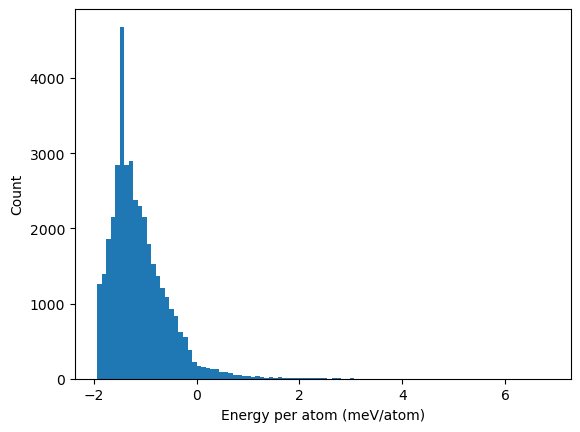

In [6]:
hist_plot = PlotEnergyHistogram(df = load_dataset.outputs.df, log_scale = False)
hist_plot.pull();

Similarly, using the `PlotForcesHistogram` Node, we can plot the forces histogram

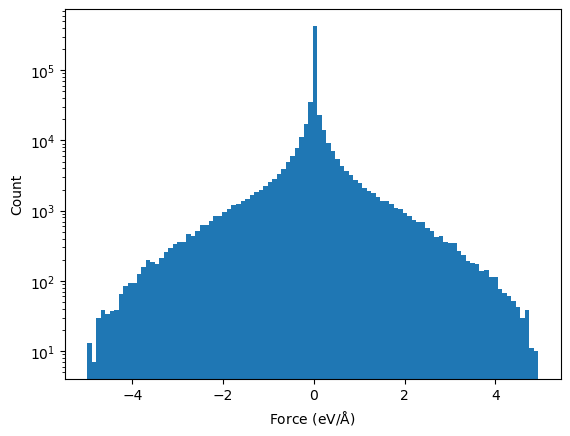

In [7]:
hist_plot = PlotForcesHistogram(df = load_dataset.outputs.df, log_scale = True)
hist_plot.pull();

## <font style="font-family:roboto;color:#455e6c"> Split the dataset into training and test </font> 

In a second step, we split the dataset into training and testing datasets.

This is done by choosing the percentage used for the training dataset through the `training_frac` parameter, where `training_frac = 0.5` means we use 50% for training and 50% for testing.

In [8]:
split_dataset = SplitTrainingAndTesting(data_df = load_dataset.outputs.df, training_frac = 0.5)
split_dataset.pull();

## <font style="font-family:roboto;color:#455e6c"> Define and specify the configuration of the ACE potential </font> 

Following the `PACEmaker` notation, we create a file similar to `input.yaml` (see the `PACEmaker` [documentation](https://pacemaker.readthedocs.io/en/latest/) for more details).

```
fit:
  fit_cycles: 1
  loss: {L1_coeffs: 1e-08, L2_coeffs: 1e-08, kappa: 0.08, w0_rad: 0, w1_rad: 0, w2_rad: 0}
  maxiter: 1000
  optimizer: BFGS
  trainable_parameters: ALL
  weighting: {DE: 1.0, DElow: 1.0, DEup: 10.0, DF: 1.0, DFup: 50.0, energy: convex_hull,
    nfit: 20000, reftype: all, seed: 42, type: EnergyBasedWeightingPolicy, wlow: 0.95}
.
.
.
potential:
  bonds:
    ALL:
      dcut: 0.01
      radbase: SBessel
      radparameters: [5.25]
      rcut: 6.0
  elements: [Mg, Ca]
  embeddings:
    ALL:
      fs_parameters: [1, 1, 1, 0.5]
      ndensity: 2
      npot: FinnisSinclairShiftedScaled
  functions:
    number_of_functions_per_element = 300
    ALL:
      lmax_by_orders: [15, 6, 2, 1]
      nradmax_by_orders: [0, 6, 3, 1]

### 1. Embeddings
specify how the atomic energy $E_i$ depends on the ACE properties/densities $\varphi$. The most approximate approach, but the most efficient for potential fitting, is the linear expansion $E_i = \varphi$. Non-linear expansions, e.g. including the square root, provide more flexibility and accuracy of the final potential, but require significantly more computational resources for fitting.

Embeddings for `ALL` species: 
- non-linear `FinnisSinclairShiftedScaled`
- 2 densities
- fs_parameters': [1, 1, 1, 0.5]:
$$E_i = 1.0 * \varphi(1)^1 + 1.0 * \varphi(2)^{0.5} = \varphi^{(1)} + \sqrt{\varphi^{(2)}} $$

### 2. Radial functions

Radial functions are defined by orthogonal polynomals. Examples are:
* (a) Exponentially-scaled Chebyshev polynomials (λ = 5.25)
* (b) Power-law scaled Chebyshev polynomials (λ = 2.0)
* (c) Simplified spherical Bessel functions

<img src="img/radial-functions-low.png" width="40%">

Radial functions specification have to be provided for `ALL` species pairs (i.e. Al-Al, Al-Li, Li-Al, Li-Li):

* based on the Simplified Bessel function
* and cutoff, e.g. $r_c=6.0$

#### 3. B-basis functions

B-basis functions  specifications for `ALL` species type interactions, i.e. Al-Al block:
* maximum order = 4, i.e. body-order 5 (1 central atom + 4 neighbour  densities)
* nradmax_by_orders: 15, 3, 2, 1
* lmax_by_orders: 0, 3, 2, 1

For simplicity, the main inputs that we will consider for the potential configurations are:

- `number_of_functions_per_element`: specifies how many functions will be provided in the potential
- `rcut`: specifies what the cutoff radius is

In [9]:
parameterize_potential = ParameterizePotentialConfig(number_of_functions = 10, rcut = 6.0)

Check the current potential configurations in dictionary format,

In [10]:
parameterize_potential.pull().to_dict()

{'deltaSplineBins': 0.001,
 'embeddings': {'ALL': {'npot': 'FinnisSinclairShiftedScaled',
   'fs_parameters': [1, 1],
   'ndensity': 1}},
 'bonds': {'ALL': {'radbase': 'SBessel',
   'radparameters': [5.25],
   'rcut': 6.0,
   'dcut': 0.01}},
 'functions': {'number_of_functions_per_element': 10,
  'ALL': {'nradmax_by_orders': [15, 6, 4, 1], 'lmax_by_orders': [0, 6, 5, 1]}}}

## <font style="font-family:roboto;color:#455e6c"> Linear fitting </font>

Finally, we run our fit with the thus defined `potential_config` and then save the potential files inside a new folder.

**Note:** Setting `verbose = True` will show all the details of building the design matrices.

In [11]:
run_linear_fit = RunLinearFit(
    potential_config = parameterize_potential,
    df_train = split_dataset.outputs.df_training,
    df_test= split_dataset.outputs.df_testing,
    verbose = False,
)

In [12]:
run_linear_fit.pull();

Restoring node outputs  befab7d58fdbef597de2e4ac15162a93e19b493b28912332de5f2bf65b2be1db RunLinearFit False
No stored data found for node:  RunLinearFit


/srv/conda/envs/notebook/lib/python3.12/site-packages/pyace/multispecies_basisextension.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


====================== TRAINING INFO ======================
Training E RMSE: 160.54 meV/atom
Training F RMSE: 105.63 meV/A
======================= TESTING INFO =======================
Testing E RMSE: 158.99 meV/atom
Testing F RMSE: 109.50 meV/A
serialization not needed


In [13]:
save_potential = SavePotential(basis = run_linear_fit.outputs.basis)

In [14]:
save_potential.pull()

Potentials "Ca_Mg_linear_potential.yaml" and "Ca_Mg_linear_potential.yace" are saved in "/home/jovyan/Linear_ace_potentials".


(<pyace.basis.ACEBBasisSet at 0x7f25ad1d6870>,
 '/home/jovyan/Linear_ace_potentials/Ca_Mg_linear_potential.yace')

## <font style="font-family:roboto;color:#455e6c"> Workflow </font>

In [15]:
workflow_name = 'LinearAceDataset'
file_path = 'data/mgca.pckl.tgz'
compression = None
training_frac = 0.5
number_of_functions_per_element = 10
rcut = 6.0

In [16]:
wf = Workflow(workflow_name)

# Workflow connections
wf.load_dataset = ReadPickledDatasetAsDataframe(
    file_path=file_path, compression=compression
)
wf.split_dataset = SplitTrainingAndTesting(
    data_df=wf.load_dataset.outputs.df, training_frac=training_frac
)
wf.parameterize_potential = ParameterizePotentialConfig(
    number_of_functions=number_of_functions_per_element, rcut=rcut
)
wf.run_linear_fit = RunLinearFit(
    potential_config=wf.parameterize_potential,
    df_train=wf.split_dataset.outputs.df_training,
    df_test=wf.split_dataset.outputs.df_testing,
    verbose=False,
)
wf.save_potential = SavePotential(basis=wf.run_linear_fit.outputs.basis)
wf.predict_energies_forces = PredictEnergiesAndForces(
    basis=wf.run_linear_fit.outputs.basis,
    df_train=wf.split_dataset.outputs.df_training,
    df_test=wf.split_dataset.outputs.df_testing,
)

INFO:root:load_dataset/df -> split_dataset/data_df
INFO:root:parameterize_potential/potential_config -> run_linear_fit/potential_config
INFO:root:split_dataset/df_training -> run_linear_fit/df_train
INFO:root:split_dataset/df_testing -> run_linear_fit/df_test
INFO:root:run_linear_fit/basis -> save_potential/basis
INFO:root:run_linear_fit/basis -> predict_energies_forces/basis
INFO:root:split_dataset/df_training -> predict_energies_forces/df_train
INFO:root:split_dataset/df_testing -> predict_energies_forces/df_test


In [17]:
wf.run()

Restoring node outputs  befab7d58fdbef597de2e4ac15162a93e19b493b28912332de5f2bf65b2be1db run_linear_fit True
Potentials "Ca_Mg_linear_potential.yaml" and "Ca_Mg_linear_potential.yace" are saved in "/home/jovyan/Linear_ace_potentials".
Restoring node outputs  1eb310ef5b03e8867339d412fa7aa03ba1252e7c4c5a141bfdc61877174b5d5c predict_energies_forces False
No stored data found for node:  predict_energies_forces
serialization not needed


{'reference_training_epa': array([-0.68663657, -0.99923799, -1.08362327, ..., -1.47605157,
        -1.44900232, -1.2044471 ]),
 'reference_training_fpa': array([-0.0000e+00, -0.0000e+00,  0.0000e+00, ...,  5.5500e-06,
         5.2099e-04,  3.0750e-05]),
 'predicted_training_epa': array([-0.81386625, -0.87184381, -0.43534825, ..., -1.51306876,
        -1.50692894, -1.07993029]),
 'predicted_training_fpa': array([ 4.44089210e-16,  5.55111512e-16, -1.83880688e-15, ...,
         3.04603864e-05,  5.53148274e-04,  5.84272215e-05]),
 'reference_testing_epa': array([-1.50104811,  0.17800853, -0.57766618, ..., -0.83208959,
        -0.25764739, -0.27296486]),
 'reference_testing_fpa': array([ 0.        ,  0.        ,  0.        , ..., -0.05524943,
        -0.03189827, -1.23912384]),
 'predicted_testing_epa': array([-1.22525141,  0.06423183, -0.70620421, ..., -0.70818788,
        -0.10829411, -0.20601877]),
 'predicted_testing_fpa': array([ 0.        ,  0.        ,  0.        , ...,  0.00609773,


## <font style="font-family:roboto;color:#455e6c"> Loading the workflow into the GUI </font>

Run the workflow using the GUI and perform a level 1 validation of our linear ACE potential.

Helpful nodes for performing this task:
- `atomistic -> mlips -> fitting -> ace`: contains all nodes to run the linear ACE fit, to plot the data histograms and the fitting's accuracy curves.

<img src="img/validation_schematic.png" width="60%">

**NOTE:** You can change the ratio of the canvas to the whole screen by changing the value of `flow_widget_ratio` between 0 to 1 (try 0.6 or 0.7)

In [18]:
pf = PyironFlow([wf])
pf.gui

Exercise: change the `number_of_functions_per_element` to a higher value (i.e., 50) and check the fitting curves. Did the fit get better or worse?

**Note:** You can save the potential under a new name using the `filename` input in `save_potential` node.

<img src="img/logo_roll.png" width="1200">